# 1. Introduction

This project presents a comprehensive comparative performance analysis of three major Nigerian equities, DANGCEM (Dangote Cement), GTCO (Guaranty Trust Holding Company), and ZENITHBANK (Zenith Bank), over a 5-year period (approximately June 2021 to June 2026).

The Nigerian stock market offers unique opportunities and challenges, characterized by high volatility, sector-specific dynamics, and exposure to macroeconomic factors such as inflation, currency fluctuations, and regulatory changes. Understanding how individual stocks behave in this environment is crucial for informed investment decisions and portfolio construction.

This analysis leverages Python and key financial data science techniques to evaluate the stocks across multiple dimensions, including returns, risk, risk-adjusted performance, and behavioral similarity.



# 2. Objective
The primary objective of this project is to:

- Evaluate and compare the historical performance of DANGCEM, GTCO, and ZENITHBANK using key financial metrics.
- Assess risk and return profiles through volatility, Sharpe Ratio, and extreme return analysis.
- Examine the diversification potential among the stocks using correlation and similarity measures (Euclidean, Manhattan, and Cosine similarity).
- Provide clear, data-driven insights that can support investment decisions in the Nigerian equities market.

### Focus Areas:

- Risk-adjusted performance comparison
- Return distribution characteristics
- Pairwise similarity and diversification benefits

# 3. Data Loading & Cleaning
The analysis is based on daily closing prices of three major Nigerian equities, DANGCEM, GTCO, and ZENITHBANK — over a 5-year period (approximately June 2021 to June 2026).

In [1]:
import datetime
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from scipy import stats

# ====================== DISPLAY SETTINGS ======================
pd.options.display.float_format = "{:,.6f}".format   # 6 decimal places + thousand separators
pd.set_option('display.max_columns', None)           # Show all columns
pd.set_option('display.width', 1000)                 # Wider display
pd.set_option('display.max_rows', 100)               # Adjust as needed
# ============================================================

sns.set_style("whitegrid")   # Clean plotting style
sns.set()

### **Data Source**

- Historical daily price data was obtained from Investing.com.
- The dataset includes `Date`, `Close` prices for each stock.

### **Data Cleaning Steps Performed:**

- Parsed and standardized date format
- Handled missing values using forward-fill where appropriate
- Removed any duplicate dates
- Ensured chronological order and consistent frequency
- Converted price columns to numeric format 

In [2]:
# Dangote Cement Stock Price
dangcem = pd.read_csv("../data/raw/Dangote Cement Stock Price History.csv", index_col="Date") 
dangcem.drop(columns=["Open", "High", "Low", "Vol.", "Change %"], inplace=True)
dangcem.rename(columns={"Price":"DANGCEM"}, inplace=True)
# Covert str => float
dangcem["DANGCEM"] = dangcem["DANGCEM"].str.replace(",","").astype("float64")

# Guaranty Trust Holding Stock Price
gtco = pd.read_csv("../data/raw/Guaranty Trust Holding Stock Price History.csv", index_col="Date") 
gtco.drop(columns=["Open", "High", "Low", "Vol.", "Change %"], inplace=True)
gtco.rename(columns={"Price":"GTCO"}, inplace=True)

# Zenith Bank Stock Price
zenith = pd.read_csv("../data/raw/Zenith Bank Stock Price History.csv", index_col="Date") 
zenith.drop(columns=["Open", "High", "Low", "Vol.", "Change %"], inplace=True)
zenith.rename(columns={"Price":"ZENITHB"}, inplace=True)

# Joined the DataFrames together
stock_prices = pd.concat([dangcem, gtco, zenith], axis=1)
stock_prices.to_csv("../data/processed/Dangcem_Gtco_Zenithb.csv", index=True)

In [3]:
start = pd.Timestamp("2021-06-21").tz_localize(None)
end = pd.Timestamp("2026-06-21").tz_localize(None)

prices = pd.read_csv("../data/processed/Dangcem_Gtco_Zenithb.csv", index_col="Date", parse_dates=True)

prices.index = pd.to_datetime(prices.index)
prices = prices.sort_index()

prices = prices.loc[start:end]
# prices = prices[prices.index.dayofweek < 5]
prices.dropna(inplace=True)
prices.head()

,DANGCEM,GTCO,ZENITHB
Date,,,
2021-06-24,230.000000,28.550000,23.800000
2021-06-25,221.000000,30.000000,23.800000
2021-06-28,221.000000,30.000000,23.650000
2021-06-29,221.000000,30.000000,23.750000
2021-06-30,221.000000,29.900000,23.750000


In [4]:
prices.shape

(1233, 3)

### **Data Summary**

- Time Period: 5 years (≈ June 2021 – June 2026)

- Frequency: Daily

- Assets: 3 stocks

- Date Range: 2021-06-21 to 2026-06-21

- Total Observations: 1233 trading days

# 4. Exploratory Data Analysis
This section provides an initial overview of the price movements and basic characteristics of the three stocks over the 5-year period.


### 4.1 Normalized Price Trends
To enable fair visual comparison, all stock prices were normalized to a starting value of 100.

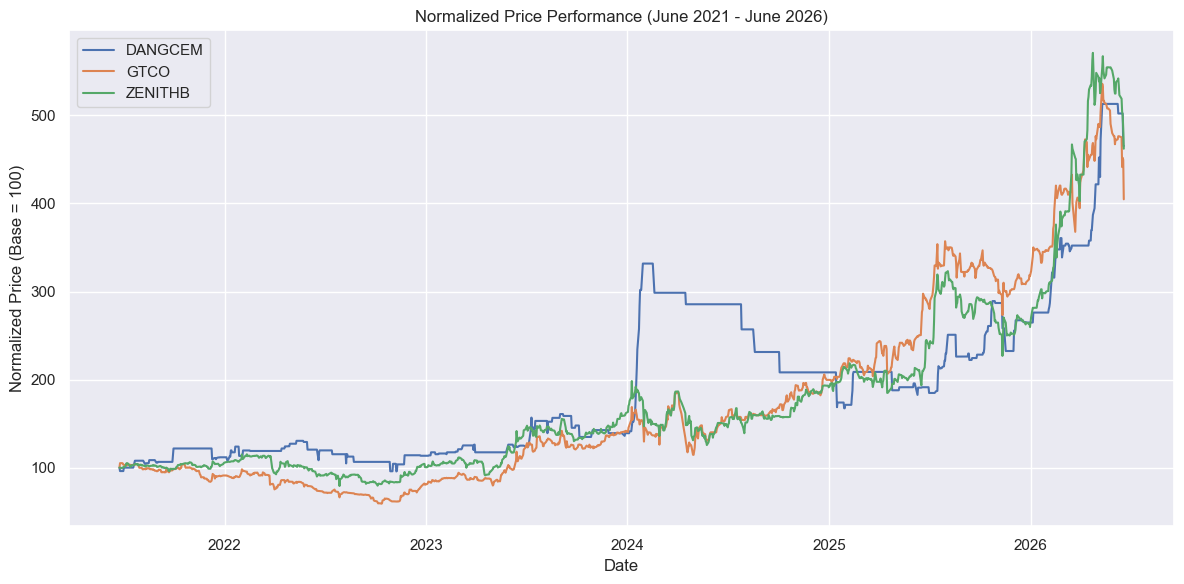

In [5]:
# Normalized Price Chart
normalized_prices = prices / prices.iloc[0] * 100

plt.figure(figsize=(12, 6))
for column in normalized_prices.columns:
    plt.plot(normalized_prices.index, normalized_prices[column], label=column)

plt.title('Normalized Price Performance (June 2021 - June 2026)')
plt.xlabel('Date')
plt.ylabel('Normalized Price (Base = 100)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 5. Return Calculation & Analysis



### I) Computing returns for all three stocks.

In [6]:
#SIMPLE RETURNS
# simple_returns = prices.pct_change().iloc[1:]

# LOG RETURNS
returns = np.log(prices) - np.log(prices.shift(1))
returns.dropna(inplace=True)

returns.head()

,DANGCEM,GTCO,ZENITHB
Date,,,
2021-06-25,-0.039917,0.049540,0.000000
2021-06-28,0.000000,0.000000,-0.006322
2021-06-29,0.000000,0.000000,0.004219
2021-06-30,0.000000,-0.003339,0.000000
2021-07-01,0.000000,-0.013468,0.006296


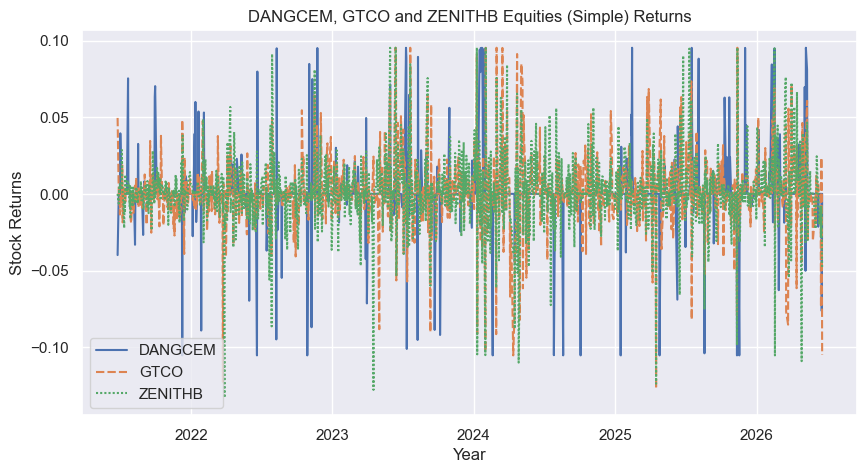

In [7]:
plt.figure(figsize=(10, 5))
sns.lineplot(returns)
plt.xlabel("Year")
plt.ylabel("Stock Returns")
plt.title("DANGCEM, GTCO and ZENITHB Equities (Simple) Returns")
plt.show()

### II) Annualized return and volatility.

#### Daily Return

In [8]:
summary_df = pd.DataFrame()

In [9]:
daily_return = returns.mean()
print("===========================")
print("Daily Average Return")
print("===========================")
print(daily_return)
print("===========================")
summary_df["DailyReturn"] = daily_return


Daily Average Return
DANGCEM   0.001248
GTCO      0.001135
ZENITHB   0.001243
dtype: float64


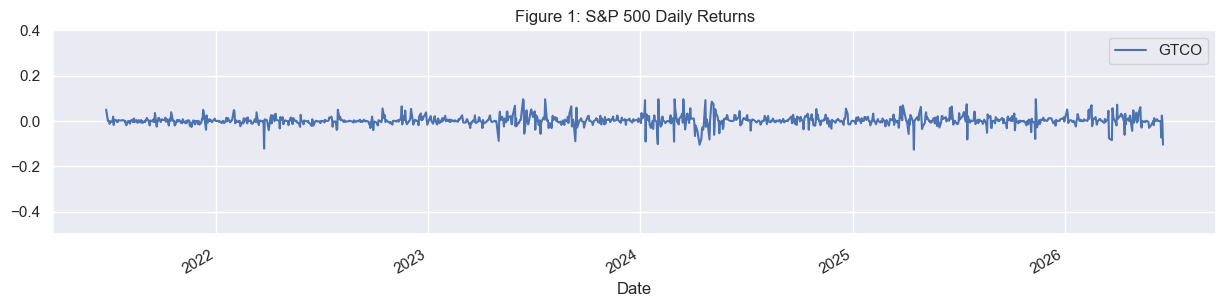

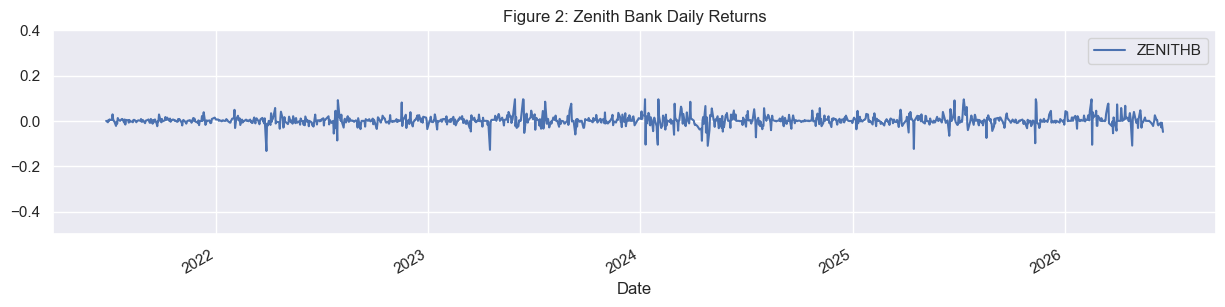

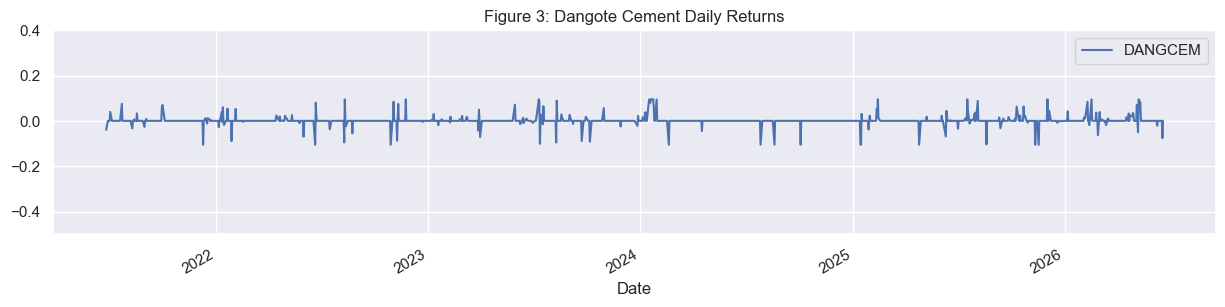

In [10]:
ax1 = returns.plot(figsize=(15, 3), y="GTCO", title="Figure 1: S&P 500 Daily Returns")
ax2 = returns.plot(figsize=(15, 3), y="ZENITHB", title="Figure 2: Zenith Bank Daily Returns")
ax3= returns.plot(figsize=(15, 3), y="DANGCEM", title="Figure 3: Dangote Cement Daily Returns")
# Set y-axis limits for both plots
ax1.set_ylim(-0.5, 0.4)
ax2.set_ylim(-0.5, 0.4)
ax3.set_ylim(-0.5, 0.4);


#### Annualized Return

In [11]:
# Using Log returns`
N = 252 # Trading days

# Geometric Annualized Return (Compounded)
annualized_return = np.prod(1+returns, axis=0)**(1/N) - 1 # Using Geometric Mean
summary_df["AnnualizedReturn"] = annualized_return

#### Volatility (Standard Deviation)

In [12]:
vols = returns.std()
summary_df["StandardDeviation"] = vols
print("===========================")
print("Volatility")
print("===========================")
print(vols)
print("===========================")

Volatility
DANGCEM   0.021055
GTCO      0.022032
ZENITHB   0.022772
dtype: float64


### III) Rolling volatility.

In [13]:
#  Rolling Volatility for 20- day

rolling_20 = (abs(prices - prices.rolling(20).mean())/prices).iloc[19:, :]
# rolling_20

#  Rolling Volatility for 50- day

rolling_50 = (abs(prices - prices.rolling(50).mean())/prices).iloc[49:, :]
# rolling_50.head()

#### 4. Moving Average Volatility


In [14]:
# 50-day Moving Average Volatility
moving_average_vol = rolling_50.mean()
summary_df["MovingAverageVolatility"] = moving_average_vol
# moving_average_vol = (abs(prices - prices.rolling(50).mean())/prices).mean()
print("50-Day Moving Average")
print("===========================")
print(moving_average_vol)
print("===========================")


50-Day Moving Average
DANGCEM   0.068414
GTCO      0.067471
ZENITHB   0.067712
dtype: float64


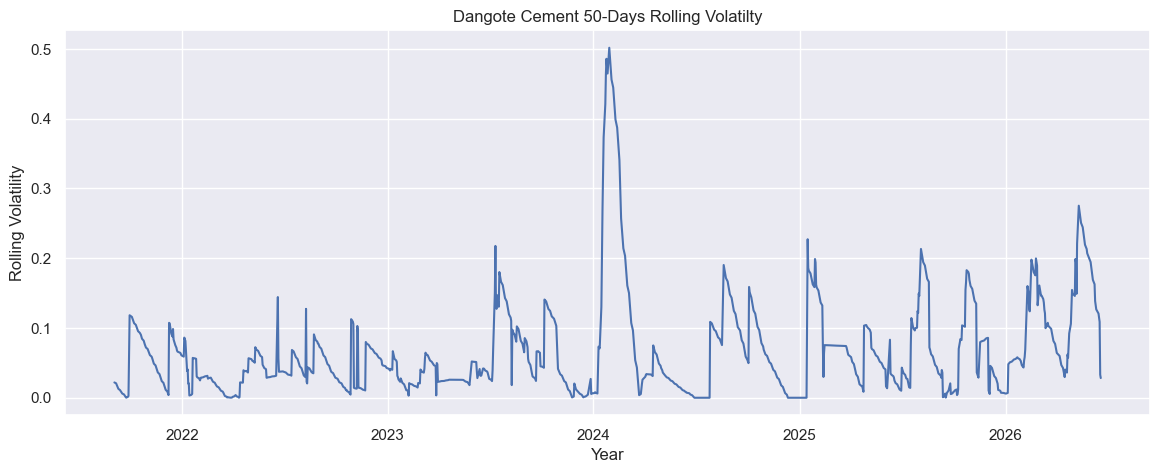

In [15]:
plt.figure(figsize=(14, 5))
sns.lineplot(x="Date", y="DANGCEM", data=rolling_50)
plt.xlabel("Year")
plt.ylabel("Rolling Volatility")
plt.title("Dangote Cement 50-Days Rolling Volatilty")
plt.show()

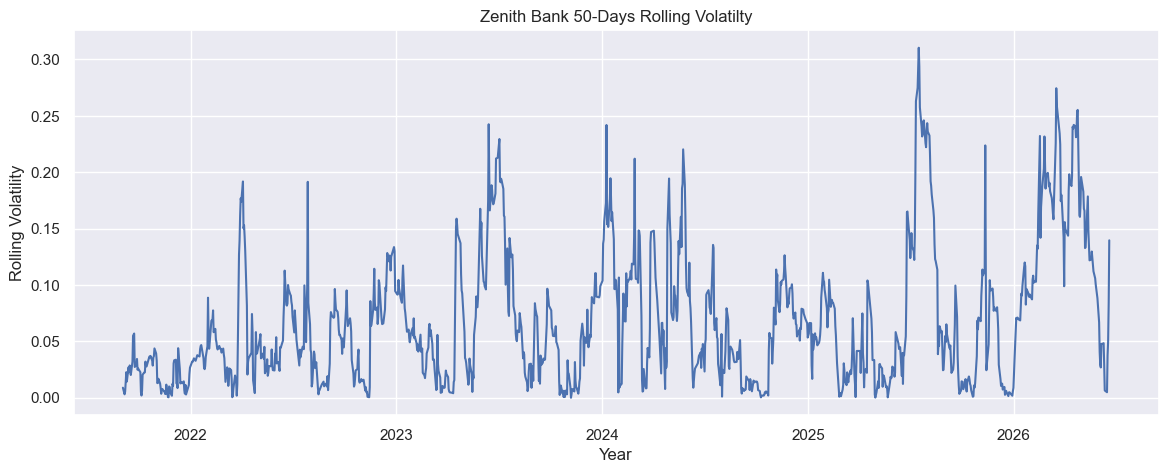

In [16]:
plt.figure(figsize=(14, 5))
sns.lineplot(x="Date", y="ZENITHB", data=rolling_50)
plt.xlabel("Year")
plt.ylabel("Rolling Volatility")
plt.title("Zenith Bank 50-Days Rolling Volatilty")
plt.show()

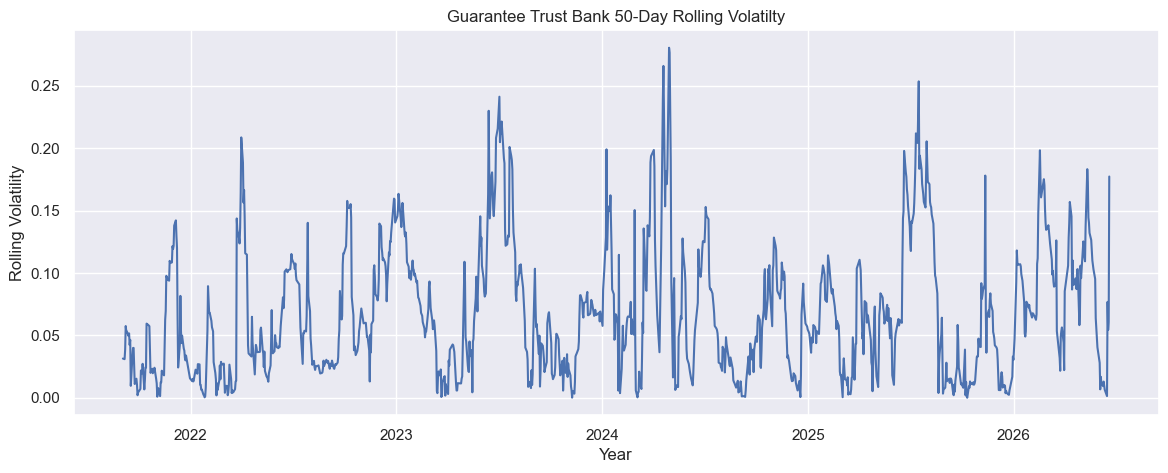

In [17]:
plt.figure(figsize=(14, 5))
sns.lineplot(x="Date", y="GTCO", data=rolling_50, legend=True)
plt.xlabel("Year")
plt.ylabel("Rolling Volatility")
plt.title("Guarantee Trust Bank 50-Day Rolling Volatilty")
plt.show()

#### 5. Sharpe Ratio

In [18]:
# Assuming it is a zero riskfree rate
sharpe_ratio = returns.mean()/returns.std()
summary_df["SharpeRatio"] = sharpe_ratio
print("===============================")
print("Sharpe Ratio")
print("===============================")
print(sharpe_ratio)
print("===============================")

Sharpe Ratio
DANGCEM   0.059266
GTCO      0.051507
ZENITHB   0.054563
dtype: float64


#### 6. Semi-variance (Deviation from Average Return)

In [19]:
semivariance = ((returns[returns < returns.mean()] - returns.mean())**2).mean()
summary_df["SemiVariance"]= semivariance
print(semivariance)
dangcem_mean = returns["DANGCEM"].mean()
gtco_mean = returns["GTCO"].mean()
zenithb_mean = returns["ZENITHB"].mean()


DANGCEM   0.000236
GTCO      0.000414
ZENITHB   0.000474
dtype: float64


This output shows that ZENITHB has a much higher semivariance (0.000474) compared to the GTCO (0.000414) and DANGCEM (0.000236). This indicates that ZENITHB has experienced significantly larger negative deviations from its average return, suggesting higher downside risk.

### IV) High-Low range analysis.

In [20]:
start = pd.Timestamp(end - datetime.timedelta(365))
# start = end - pd.DateOffset(years=1)

In [21]:
currYear = prices.loc[start:end]

In [22]:
low = currYear.min()
high = currYear.max()
high_low = (high - low)/prices.iloc[-1, :]
summary_df["HighMinusLow"] = high_low
print("===============================")
print("High Minus Low Range Analysis")
print("===============================")
print(high_low)
print("===============================")

High Minus Low Range Analysis
DANGCEM   0.705607
GTCO      0.649070
ZENITHB   0.773182
dtype: float64


# Section 4: Matrix Analysis


### I) Covariance Matrix

In [23]:
covariance = returns.cov()
covariance

,DANGCEM,GTCO,ZENITHB
DANGCEM,0.000443,0.000014,0.000030
GTCO,0.000014,0.000485,0.000282
ZENITHB,0.000030,0.000282,0.000519


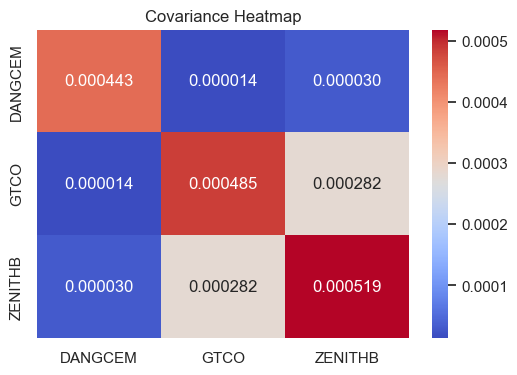

In [24]:
plt.figure(figsize=(6, 4))
sns.heatmap(
    covariance,
    annot=True,
    cmap="coolwarm",
    fmt=".6f",
    xticklabels=covariance.columns,
    yticklabels=covariance.columns
)
plt.title("Covariance Heatmap")
plt.show()


### II) Correlation Matrix

In [25]:
corr = returns.corr()
corr

,DANGCEM,GTCO,ZENITHB
DANGCEM,1.000000,0.030659,0.063382
GTCO,0.030659,1.000000,0.561799
ZENITHB,0.063382,0.561799,1.000000


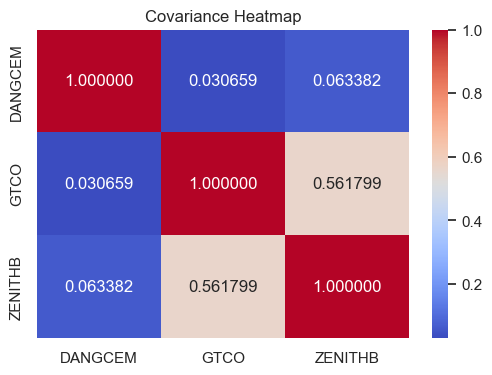

In [26]:
plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".6f")
plt.title("Covariance Heatmap")
plt.show()

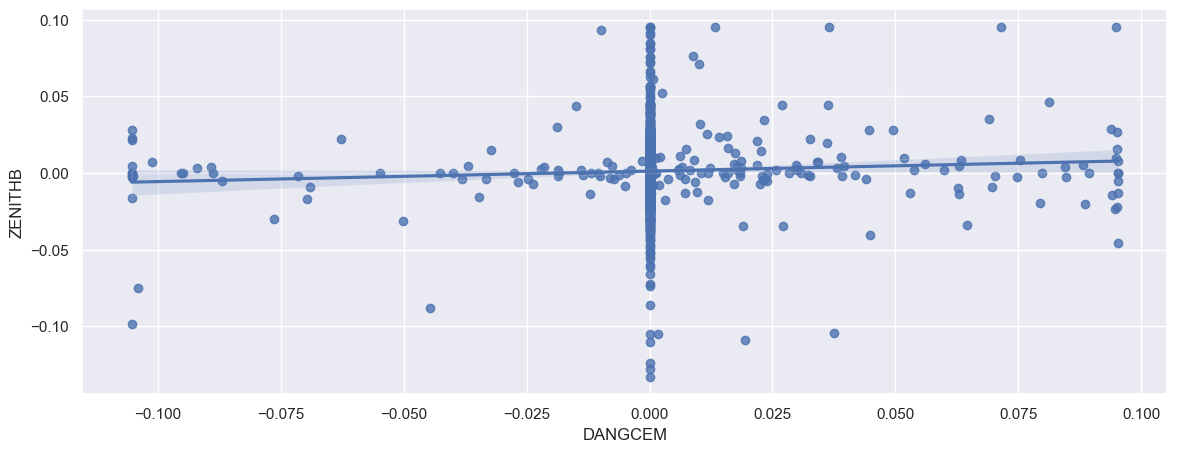

In [27]:
plt.figure(figsize=(14, 5))
sns.regplot(x='DANGCEM', y="ZENITHB", data=returns)
plt.show()

### III) Check for Symmetry & Positive Definiteness

In [28]:
def is_symmetric_positive_definite(matrix):
    eigvals = np.linalg.eigvals(matrix) # Eigen Valeus
    det = np.linalg.det(matrix) # Determinant
    if np.allclose(matrix, matrix.T):
        if np.all(eigvals > 0) and np.all(det > 0):
            return "Matrix is a Symmetric Positive Definite Matrix"
        elif np.all(eigvals >= 0) and np.all(det >= 0):
            return "Matrix is a Symmetric Semipositive Definite"
    return "Matrix is neither Positive nor Semipositive Definite"    

In [29]:
is_symmetric_positive_definite(covariance)

'Matrix is a Symmetric Positive Definite Matrix'

### IV) Testing for Skewness

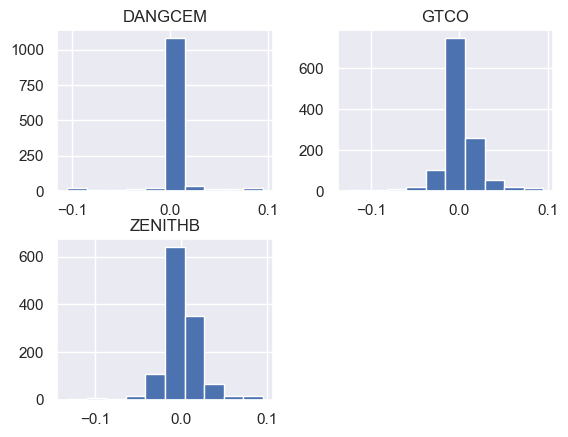

In [30]:
returns.hist(bins=10);

#### i) To determine how many data points we have on either side of the mean

The below code takes the count of data points greater than the mean and divides it by the total number of data points. This will give us the percentage of data points greater than the mean.



In [31]:
dangcem_skewness = (len(returns[returns.DANGCEM > returns.DANGCEM.mean()])) / (len(returns))
print("DANGCEM Skewness: ", dangcem_skewness)
gtco_skewness = (len(returns[returns.GTCO > returns.GTCO.mean()])) / (len(returns))
print("GTCO Skewness: ", gtco_skewness)
zenithb_skewness = (len(returns[returns.ZENITHB > returns.ZENITHB.mean()])) / (len(returns))
print("ZENITHB Skewness: ", zenithb_skewness)

DANGCEM Skewness:  0.09740259740259741
GTCO Skewness:  0.42045454545454547
ZENITHB Skewness:  0.45454545454545453


**Recall:** A value close to 0.5 suggests a roughly symmetrical distribution, while a value significantly greater than 0.5 suggests a negative skew (more returns below the mean).

 ii) Conducting a Normality Test 
Using `normaltest()`

In [32]:
dangcem = stats.normaltest(np.array(returns.DANGCEM))
gtco = stats.normaltest(np.array(returns.GTCO))
zenithb = stats.normaltest(np.array(returns.ZENITHB))
print("==============================================================")
print("The Results of Normality")
print("==============================================================")
print("DANGCEM\npvalue = ", dangcem.pvalue, "\nstatistics =", dangcem.statistic)
print("==============================================================")
print("GTCO\npvalue = ", gtco.pvalue, "\nstatistics =", gtco.statistic)
print("==============================================================")
print("ZENITHB\npvalue = ", zenithb.pvalue, "\nstatistics =", zenithb.statistic)
print("==============================================================")

The Results of Normality
DANGCEM
pvalue =  1.8571603867423513e-62 
statistics = 284.2824542365081
GTCO
pvalue =  1.2142109941361424e-41 
statistics = 188.42378866889808
ZENITHB
pvalue =  5.428412269948837e-44 
statistics = 199.24419480038074


**Recall:**
- Statistic: A test statistic that measures the deviation from normality. Higher values indicate a greater deviation.
- p-value: The probability of observing the data if it were truly normally distributed. A small p-value (typically less than 0.05) suggests that the data is not normally distributed.

iii) Testing Skewness and Kurtosis 
Using `stats.jarque_bera()`
If **p_value < 0.05** indicates that the data is **not** normally distributed

In [33]:
dangcem_pvalue = stats.jarque_bera(np.array(returns.DANGCEM)).pvalue
gtco_pvalue = stats.jarque_bera(np.array(returns.GTCO)).pvalue
zenithb_pvalue = stats.jarque_bera(np.array(returns.ZENITHB)).pvalue
print("=" * 80)
print("P-values of Each Equity using Jarque_bera Normality Test")
print("=" * 80)
print("DANGCEM p_value:", dangcem_pvalue)
print("GTCO p_value:", gtco_pvalue)
print("ZENITHB p_value:", zenithb_pvalue)
print("=" * 80)

P-values of Each Equity using Jarque_bera Normality Test
DANGCEM p_value: 0.0
GTCO p_value: 0.0
ZENITHB p_value: 0.0


> *Returns are not normally distributed (Jarque-Bera p-value = 0.0 for all stocks), which is typical in financial data.*

### iv) Does Our Gaussian Distribution Break Down?

In [34]:
# ====================== EXTREME RETURNS ANALYSIS ======================

print("EXTREME RETURNS ANALYSIS (in terms of Standard Deviations from Mean)")
print("=" * 80)

extreme_summary = []

for stock in returns.columns:
    data = returns[stock]
    mean_ret = data.mean()
    std_ret = data.std()
    
    max_ret = data.max()
    min_ret = data.min()
    
    dev_max = (max_ret - mean_ret) / std_ret
    dev_min = (min_ret - mean_ret) / std_ret
    
    extreme_summary.append({
        'Stock': stock,
        'Max Return': round(max_ret, 5),
        'Min Return': round(min_ret, 5),
        'Max Dev from Mean': round(dev_max, 4),
        'Min Dev from Mean': round(dev_min, 4)
    })

extreme_df = pd.DataFrame(extreme_summary)
print(extreme_df.to_string(index=False))

print("\n" + "="*80)
print("Interpretation: Higher positive deviation in Max Return or more negative in Min Return indicates fatter tails / higher extreme risk.")

EXTREME RETURNS ANALYSIS (in terms of Standard Deviations from Mean)
  Stock  Max Return  Min Return  Max Dev from Mean  Min Dev from Mean
DANGCEM    0.095310   -0.105360           4.467500          -5.063400
   GTCO    0.095310   -0.127160           4.274600          -5.823000
ZENITHB    0.095310   -0.133000           4.130800          -5.895000

Interpretation: Higher positive deviation in Max Return or more negative in Min Return indicates fatter tails / higher extreme risk.


In [35]:
stats.norm.cdf(-0.105361)

np.float64(0.458044680630599)

In [41]:
desired_order = [
    'AnnualizedReturn',
    'DailyReturn',
    'StandardDeviation',
    'MovingAverageVolatility',
    'SharpeRatio',
    'SemiVariance',
    'HighMinusLow'
]

# Work with the DataFrame first
summary_df = summary_df[desired_order].copy()

# Convert selected columns to percentages (numeric * 100)
percent_cols = ['AnnualizedReturn', 'DailyReturn', 'StandardDeviation', 
                'MovingAverageVolatility', 'HighMinusLow']

summary_df[percent_cols] = summary_df[percent_cols] * 100

# Only after all numeric work, apply styling
summary_df = summary_df.style.format({
    'AnnualizedReturn': "{:.2f}%",
    'DailyReturn': "{:.3f}%",
    'StandardDeviation': "{:.2f}%",
    'MovingAverageVolatility': "{:.2f}%",
    'HighMinusLow': "{:.2f}%",
    'SharpeRatio': "{:.4f}",
    'SemiVariance': "{:.6f}"
}).set_caption("Summary Statistics of the Three Equities")

Pairwise Similarity Measures:


,Euclidean Distance,Manhattan Distance,Cosine Similarity
Pair,,,
DANGCEM - ZENITHB,1.053214,22.215521,0.066403
DANGCEM - GTCO,1.052723,21.788254,0.033610
ZENITHB - GTCO,0.736180,17.310483,0.563025


In [44]:
summary_df

,AnnualizedReturn,DailyReturn,StandardDeviation,MovingAverageVolatility,SharpeRatio,SemiVariance,HighMinusLow
DANGCEM,0.50%,0.125%,2.11%,6.84%,0.0593,0.000236,70.56%
GTCO,0.44%,0.113%,2.20%,6.75%,0.0515,0.000414,64.91%
ZENITHB,0.48%,0.124%,2.28%,6.77%,0.0546,0.000474,77.32%


In [45]:
summary_df.to_excel("../outputs/summary_statistics.xlsx", engine="openpyxl")

**Interpretation of Summary Statistics**

The table above presents key risk and return metrics for the three stocks over the observed period of 5 years:

- DANGCEM stands out as the strongest performer on a risk-adjusted basis. It achieved the highest daily return (0.001248) while maintaining the lowest volatility (Standard Deviation = 0.021055). This is further confirmed by its highest Sharpe Ratio (0.0593), indicating superior return per unit of risk.
- ZENITHBANK delivered a very similar daily return to DANGCEM (0.001243) but with noticeably higher volatility (0.022772) and a lower Sharpe Ratio (0.0546). This suggests it carried more risk for roughly the same return.
- GTCO recorded the lowest daily return (0.001135) and relatively moderate volatility. It appears to be the most conservative of the three but also the least rewarding in terms of return.


**Overall Insights:**

1. DANGCEM is the clear winner in terms of risk-adjusted performance among the three stocks.
2. Banking stocks (ZENITHBANK and GTCO) showed higher volatility compared to the Industrial Goods stock (DANGCEM), which is expected due to their sensitivity to interest rates and regulatory changes.
3. The combination of DANGCEM with either of the banks could offer good diversification, especially considering the low similarity measures observed earlier.

### Similarity Measures

#### Similarity Measures on DANGCEM, ZENITHBank and GTCO

In [47]:
# ====================== PAIRWISE SIMILARITY MEASURES ======================

stocks = ['DANGCEM', 'GTCO', 'ZENITHB']
pairs = [('DANGCEM', 'ZENITHB'), ('DANGCEM', 'GTCO'), ('ZENITHB', 'GTCO')]

similarity_results = []

for stock1, stock2 in pairs:
    series1 = returns[stock1]
    series2 = returns[stock2]
    
    # Euclidean Distance
    euclidean = np.sqrt(np.sum((series1 - series2)**2))
    
    # Manhattan Distance
    manhattan = np.sum(np.abs(series1 - series2))
    
    # Cosine Similarity
    dot_product = np.dot(series1, series2)
    magnitude1 = np.linalg.norm(series1)
    magnitude2 = np.linalg.norm(series2)
    cosine = dot_product / (magnitude1 * magnitude2)
    
    similarity_results.append({
        'Pair': f"{stock1} - {stock2}",
        'Euclidean Distance': round(euclidean, 6),
        'Manhattan Distance': round(manhattan, 6),
        'Cosine Similarity': round(cosine, 6)
    })

# Final DataFrame
similarity_measures = pd.DataFrame(similarity_results)
similarity_measures.set_index('Pair', inplace=True)

# load to excel file
similarity_measures.to_excel("../outputs/similarity_measures.xlsx", engine="openpyxl")

print("Pairwise Similarity Measures:")
display(similarity_measures)

Pairwise Similarity Measures:


,Euclidean Distance,Manhattan Distance,Cosine Similarity
Pair,,,
DANGCEM - ZENITHB,1.053214,22.215521,0.066403
DANGCEM - GTCO,1.052723,21.788254,0.033610
ZENITHB - GTCO,0.736180,17.310483,0.563025


**Pairwise Similarity Analysis**
> The analysis reveals that ZENITHBANK and GTCO exhibit moderate similarity in their return patterns (Cosine Similarity = 0.563), while DANGCEM shows low similarity with both banking stocks. This suggests good diversification potential when combining DANGCEM with banking stocks.

**Key Insights:**

- ZENITHBANK and GTCO (both from the Financial Services sector) show the highest similarity in their return behavior. This makes sense, banks tend to react similarly to interest rate changes, economic policy, and regulatory news.
- DANGCEM (Industrial Goods / Cement sector) has very low similarity with both banks. This is excellent for diversification, DANGCEM moves differently from the banking stocks.
- Overall, the three stocks are not highly correlated in their daily movements, which is positive from a portfolio diversification perspective.

# Key Findings

The comparative analysis of DANGCEM, GTCO, and ZENITHBANK over the 5-year period (2021–2026) reveals the following insights:

**Performance Summary:**

- **DANGCEM** emerged as the **strongest performer** on a risk-adjusted basis. It delivered the highest annualized return while maintaining the **lowest volatility** among the three stocks, resulting in the **highest Sharpe Ratio**.
- **ZENITHBANK** showed competitive returns but with noticeably **higher volatility** compared to DANGCEM.
- **GTCO** recorded the lowest returns with relatively moderate volatility, making it the most conservative of the three.

**Risk & Distribution Characteristics**

- All three stocks exhibited **negative skewness**, indicating a higher probability of extreme negative returns (fat left tail).
- Returns **are not normally distributed** (confirmed by Jarque-Bera test with p-value = 0.0 for all stocks), which is typical in equity markets.

**Similarity & Diversification**

- **ZENITHBANK and GTCO** (both Financial Services sector) show **moderate similarity** in their return patterns (Cosine Similarity ≈ 0.563).
- **DANGCEM** (Industrial Goods sector) demonstrates **very low similarity** with both banking stocks (Cosine Similarity < 0.07).
- This low correlation between DANGCEM and the banking stocks suggests **strong diversification potential** when combining Industrial Goods with Financial Services stocks.

**Overall Insight**

DANGCEM offered the best balance of return and risk during the period, while the two banking stocks moved more in tandem. The low similarity between DANGCEM and the banks highlights the benefit of sector diversification in the Nigerian market.